In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(project_root)
if project_root not in sys.path:
    sys.path.append(project_root)

c:\Users\Camille\Documents\TWR\deep_agents_twr


In [2]:
from deepagents import create_deep_agent, CompiledSubAgent
from langchain.agents import create_agent
from app.tools.data_tools import *
from app.tools.metrics_agent_tools import *
from app.agents.prompts.data_analist_prompt import DATA_ANALYST_PROMPT
from app.agents.prompts.data_engineer_prompt import DATA_ENGINEER_PROMPT
from app.agents.prompts.ml_analist_prompt import ML_ANALYST_PROMPT
from app.agents.prompts.orchestrator_prompt import ORCHESTRATOR_SYSTEM_PROMPT

c:\Users\Camille\Documents\TWR\deep_agents_twr\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Camille\Documents\TWR\deep_agents_twr\.venv\Lib\site-packages\motor\core.py:171: UserWarning: You appear to be connected to a DocumentDB cluster. For more information regarding feature compatibility and support please visit https://www.mongodb.com/supportability/documentdb
  delegate = self.__delegate_class__(*args, **kwargs)


Garantindo índices...
Using 11 out of 12 cores


In [3]:
from langfuse import Langfuse, get_client
from langfuse.langchain import CallbackHandler

import os

Langfuse(
    public_key=os.getenv("LANGFUSE_PUBLIC_KEY"),
    secret_key=os.getenv("LANGFUSE_SECRET_KEY"),
    host="https://cloud.langfuse.com" 
)

langfuse = get_client()
langfuse_handler = CallbackHandler()

In [4]:
data_eng_tools = [query_sql_campaigns, traffic_source_by_campaign, query_mongo_requests]
ml_specialist_tools = [run_ml_inference_pipeline, get_dataset_health_check]
data_analyst_tools = [compare_mismatch_frequencies, clear_directory]

In [5]:
from langchain_openai import ChatOpenAI

llm_fast = ChatOpenAI(
      model="gpt-4.1-mini"
)

llm_reasoning = ChatOpenAI(
      model="gpt-4o"
)

In [6]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from pydantic import BaseModel

# ==========================================
# 1. Definição do Estado Global (A "Mochila")
# ==========================================
class SecOpsState(MessagesState):
    next_agent: str 

# ==========================================
# 2. Criando os Subagentes (Nós Especialistas)
# ==========================================
data_engineer_agent = create_agent(llm_fast, tools=data_eng_tools, system_prompt=DATA_ENGINEER_PROMPT)
ml_specialist_agent = create_agent(llm_fast, tools=ml_specialist_tools, system_prompt=ML_ANALYST_PROMPT)
data_analyst_agent = create_agent(llm_fast, tools=data_analyst_tools, system_prompt=DATA_ANALYST_PROMPT)

# ==========================================
# 3. Wrappers dos Nós (Assinando as mensagens)
# ==========================================
async def data_engineer_node(state: SecOpsState):
    result = await data_engineer_agent.ainvoke({"messages": state["messages"]})
    last_msg = result["messages"][-1]
    return {"messages": [AIMessage(content=last_msg.content, name="data_engineer")]}

async def ml_specialist_node(state: SecOpsState):
    result = await ml_specialist_agent.ainvoke({"messages": state["messages"]})
    last_msg = result["messages"][-1]
    return {"messages": [AIMessage(content=last_msg.content, name="ml_specialist")]}

async def data_analyst_node(state: SecOpsState):
    result = await data_analyst_agent.ainvoke({"messages": state["messages"]})
    last_msg = result["messages"][-1]
    return {"messages": [AIMessage(content=last_msg.content, name="bot_data_analyst")]}

# ==========================================
# 4. O Nó do Supervisor (O Orquestrador)
# ==========================================
class Router(BaseModel):
    next: Literal["data_engineer", "ml_specialist", "bot_data_analyst", "FINISH"]

async def supervisor_node(state: SecOpsState):
    messages = state["messages"]
    
    # 4.1 O Orquestrador decide o próximo passo usando Structured Output
    routing_chain = llm_fast.with_structured_output(Router)
    routing_prompt = (
        "You are a supervisor managing a team: data_engineer, ml_specialist, bot_data_analyst.\n"
        "Look at the conversation history. Route to the agent that needs to act next based on the workflow.\n"
        "If 'bot_data_analyst' has already provided their findings, select FINISH."
    )
    decision = await routing_chain.ainvoke([{"role": "system", "content": routing_prompt}] + messages)
    
    # 4.2 Se ele decidiu FINISH, ele gera o Relatório Executivo Final e encerra
    if decision.next == "FINISH":
        final_msg = await llm_reasoning.ainvoke([{"role": "system", "content": ORCHESTRATOR_SYSTEM_PROMPT}] + messages)
        return {"messages": [AIMessage(content=final_msg.content, name="orchestrator")], "next_agent": "FINISH"}
        
    return {"next_agent": decision.next}


def supervisor_router(state: SecOpsState) -> str:
    if state["next_agent"] == "FINISH":
        return END
    return state["next_agent"]


workflow = StateGraph(SecOpsState)

# Adicionando os nós
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("data_engineer", data_engineer_node)
workflow.add_node("ml_specialist", ml_specialist_node)
workflow.add_node("bot_data_analyst", data_analyst_node)

# O fluxo sempre começa e volta para o supervisor
workflow.add_edge(START, "supervisor")
workflow.add_edge("data_engineer", "supervisor")
workflow.add_edge("ml_specialist", "supervisor")
workflow.add_edge("bot_data_analyst", "supervisor")

workflow.add_conditional_edges(
    "supervisor", 
    supervisor_router,
    {
        "data_engineer": "data_engineer",
        "ml_specialist": "ml_specialist",
        "bot_data_analyst": "bot_data_analyst",
        END: END
    }
)

langgraph_agent = workflow.compile()

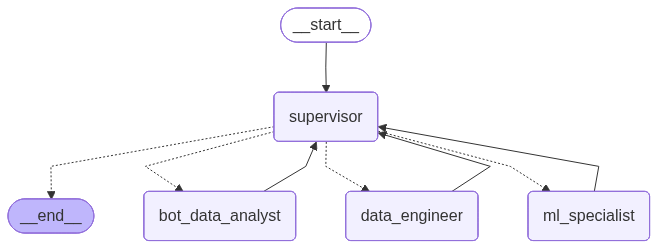

In [7]:
from IPython.display import Image, display

imagem_grafo = langgraph_agent.get_graph().draw_mermaid_png()
display(Image(imagem_grafo))
    

In [8]:
user_query = (
    "Please analyze the recent traffic from the 'google' source. "
    "1. Fetch the raw data. "
    "2. Run the ML inference pipeline. "
    "3. Analyze the False Positives (FP) and False Negatives (FN) to see if our model hallucinated or if the original human and bot labels were wrong. "
    "Finally, give me the Executive Summary formatted with tables as instructed."
)

response = await langgraph_agent.ainvoke(
    {"messages": [("user", user_query)]},
    config={"callbacks": [langfuse_handler]}
)

from utils import format_messages
format_messages(response["messages"])

Start Date:  None
End date:  None
Results:  13448
2026-03-06 14:47:45,490 - INFO - Found credentials in environment variables.
Local file already updated: fasttext_google.model
Local file already updated: fasttext_google.model.syn1neg.npy
Local file already updated: fasttext_google.model.wv.vectors_ngrams.npy
Local file already updated: fasttext_google.model.wv.vectors_vocab.npy
[INFO] FastText model não encontrado em models/google/fasttext_google.model. Tentando buscar do S3...
[DEBUG] Model Path FASTTEXT: models/google/fasttext_google.model
2026-03-06 14:47:48,579 - INFO - loading FastText object from models/google/fasttext_google.model
2026-03-06 14:47:48,613 - INFO - loading wv recursively from models/google/fasttext_google.model.wv.* with mmap=None
2026-03-06 14:47:48,613 - INFO - loading vectors_vocab from models/google/fasttext_google.model.wv.vectors_vocab.npy with mmap=None
2026-03-06 14:47:48,703 - INFO - loading vectors_ngrams from models/google/fasttext_google.model.wv.vect

Criando Vocabulário: 100%|██████████| 13448/13448 [00:04<00:00, 3116.19it/s]


Using 11 out of 12 cores


Vetorizando: 100%|██████████| 13448/13448 [01:49<00:00, 122.42it/s]


Finishing encoding
Baseline:                   datetime decision  \
0 2026-03-06 17:47:26.736     bots   
1 2026-03-06 17:34:48.509     bots   
2 2026-03-06 17:33:19.201     bots   
3 2026-03-06 17:31:09.328     bots   
4 2026-03-06 17:22:52.658     bots   

                                             headers  \
0  {"Host":"aff.conectadosimples.online","X-Reque...   
1  {"Host":"lp.matheuzinmegan.shop","X-Request-Id...   
2  {"Host":"seguro.portalrastreioencomenda.site",...   
3  {"Host":"lp.vrexsilver.shop","X-Request-Id":"c...   
4  {"Host":"lp.vrexsilver.shop","X-Request-Id":"7...   

                                       ip                  ip_api_isp  \
0                          131.196.109.90     fgtech informatica ltda   
1                           66.249.83.129                  google llc   
2  2a00:79e1:abe:1c01:e5bf:6770:435a:b880                  google llc   
3  2603:6010:9504:39fc:c1c6:4a0f:afe:b4ff  charter communications inc   
4  2603:6010:9504:39fc:c1c6:4a0f:afe:b4

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Please analyze the recent traffic from the 'google' source. 1. Fetch the raw data. 2. Run the ML inference      │
│ pipeline. 3. Analyze the False Positives (FP) and False Negatives (FN) to see if our model hallucinated or if   │
│ the original human and bot labels were wrong. Finally, give me the Executive Summary formatted with tables as   │
│ instructed.                                                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ The raw data for the recent traffic from the 'google' source has been fetched successfully, with a total of     │
│ 13,448 HTTP requests retrieved. The data is saved in the file at path: temp_data/raw_google_2117cc02.parquet.   │
│                                                                                                                 │
│ Please note that I have only fetched the raw data as per my responsibilities. The ML inference, analysis of     │
│ False Positives and False Negatives, and the preparation of the Executive Summary with tables should be         │
│ performed by the next agent in the workflow.                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ The ML inference pipeline has completed successfully for the 'google' traffic source.                           │
│                                                                                                                 │
│ Here are the key classification metrics:                                                                        │
│ - Total samples evaluated: 13,448                                                                               │
│ - Model Accuracy: 84.56%                                                                                        │
│ - False Positives (Real = Human, Predicted = Bot): 521                                                          │
│ - False Negatives (Real = Bot, Predicted = Human): 1,555                                                        │
│                                                                                                                 │
│ The processed results with predictions have been saved to: temp_data/results_google_2117cc02.parquet            │
│                                                                                                                 │
│ Next Steps:                                                                                                     │
│ Please pass this results file path and the above metrics to the Data Analyst for detailed investigation of      │
│ False Positives and False Negatives to identify potential label errors or model hallucinations.                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Executive Summary: Analysis of False Positive (FP) and False Negative (FN) Mismatches in 'google' Traffic       │
│                                                                                                                 │
│ I conducted a thorough analysis of both False Positives (FP: Human labeled unsafe but predicted bot) and False  │
│ Negatives (FN: Human labeled bot but predicted unsafe) from the ML model, comparing anomalous HTTP header       │
│ patterns in these error subsets against the entire baseline distribution.                                       │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ 1. False Positives (FP) Analysis (Human=Unsafe, ML=Bot)                                                         │
│ ----------------------------------------------------------------------------------------------------------      │
│ | Feature Type | Key               | Value               | Total FP Count | Pct Bots Baseline | Baseline        │
│ Occurrences | Conclusion                        |                                                               │
│ |--------------|-------------------|---------------------|----------------|-------------------|---------------- │
│ ------|---------------------------------|                                                                       │
│ | Header       | Accept-Encoding   | gzip, br            | 521            | 100%              | High (~808      │
│ total)     | ML Correct - historically bot    |                                                                 │
│ | Header       | Accept            | */*                 | 521            | 100%              | High (~808      │
│ total)     | ML Correct - historically bot    |                                                                 │
│ | Header       | Cf-Visitor        | {"scheme":"https"}  | 521            | 100%              | High (~808      │
│ total)     | ML Correct - historically bot    |                                                                 │
│ | Header       | X-Http-Method     | POST                | 521            | 100%              | High (~808      │
│ total)     | ML Correct - historically bot    |                                                                 │
│ | Header       | X-Forwarded-Proto | http                | 521            | 100%              | High (~808      │
│ total)     | ML Correct - historically bot    |                                                                 │
│ | Header       | X-Forwarded-Port  | 80                  | 521            | 100%              | High (~808      │
│ total)     | ML Correct - historically bot    |                                                                 │
│ | Header       | X-Http-Version    | HTTP/2              | 521            | 71.53%            | Significant     │
│ (~693)    | ML Likely Correct                |                                                                  │
│ | Header       | Ip-Api-Hosting    | 0                   | 521            | 61.88%            | Moderate (654)  │
│ | Mixed signal, but leans bot      |                                                                            │
│ | Header       | Others (many)     | Various             | 521            | ~100%              | High           │
│ | ML Correct - strong bot signals  |                                                                            │
│                                                                                                                 │
│ Summary: Most FP patterns have near 100% historical bot

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ =====================================================================                                           │
│ Executive Security Report — Ad Protection                                                                       │
│ =====================================================================                                           │
│                                                                                                                 │
│ 1) AI ANALYSIS SUMMARY                                                                                          │
│ ---------------------------------------------------------------------                                           │
│ - We analyzed a total of 13,448 HTTP requests from the 'google' source. The AI model achieved an accuracy of    │
│ 84.56%.                                                                                                         │
│ - The AI predictions included 521 false positives (FP) and 1,555 false negatives (FN).                          │
│ - Examination of discrepancies revealed that the AI correctly identified disguised bots in false positives,     │
│ while the false negatives comprised mislabeled human traffic due to legacy system errors.                       │
│                                                                                                                 │
│ 2) SUSPICIOUS BEHAVIOR FOUND                                                                                    │
│ ---------------------------------------------------------------------                                           │
│ - Feature Mismatches                                                                                            │
│ - The AI identified several headers with nearly 100% historical bot association, indicating that the traffic    │
│ flagged as false positives was indeed bot traffic. Notable fields include "Accept-Encoding: gzip, br",          │
│ "X-Http-Method: POST", and specific proxying patterns like "Cf-Visitor: {\"scheme\":\"https\"}". These headers  │
│ are characteristic of automated traffic, often unseen in human user requests.                                   │
│                                                                                                                 │
│ 3) RECOMMENDED BLOCKING RULES                                                                                   │
│ ---------------------------------------------------------------------                                           │
│ No statistically significant or reliable discoveries were found to create new blocking rules based on           │
│ deterministic bot identifiers. However, continued monitoring and analysis of high-confidence bot-like headers   │
│ described above are advised for strategic traffic management. The AI performed robustly in detecting hidden     │
│ bots; ensure current labeling systems for legacy bot detection are reviewed for accuracy improvements.          │
│                                                                                                                 │
│ In conclusion, while the AI proves effective in isolating bot traffic that may have been missed by traditional  │
│ methods, adjustments in human labeling practices could further enhance overall traffic quality assessments.     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯